In [1]:
#importing the librararies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import pmdarima as pm

In [2]:
#Loading the dataset
df= pd.read_csv("C:/Users/saiha/Desktop/Analytics_T5/Project/TM_H1.csv")

In [3]:
df = df.dropna(axis =1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Quarter    40 non-null     object
 1   Net Sales  40 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 772.0+ bytes


In [4]:
df.head(20)

,Quarter,Net Sales
0,30-09-2025,12751
1,30-06-2025,15546
2,31-03-2025,19869
3,31-12-2024,17040
4,30-09-2024,15518
5,30-06-2024,16732
6,31-03-2024,20260
7,31-12-2023,18668
8,30-09-2023,18403
9,30-06-2023,15733


In [5]:
df.rename(columns={'Quarter': 'Date'}, inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       40 non-null     object
 1   Net Sales  40 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 772.0+ bytes


In [7]:
df['Date'] = pd.to_datetime(df['Date'], format = 'mixed')

In [8]:
# Setting the date column as the index, check whether the date column is datetime64 datatype otherwise change it 
df = df.set_index(df['Date']).drop('Date', axis=1)

In [9]:
df.head()

,Net Sales
Date,
2025-09-30,12751
2025-06-30,15546
2025-03-31,19869
2024-12-31,17040
2024-09-30,15518


In [10]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Net Sales,40.0,14311.65,3935.61249,2634.0,10834.5,14821.5,17086.0,20260.0


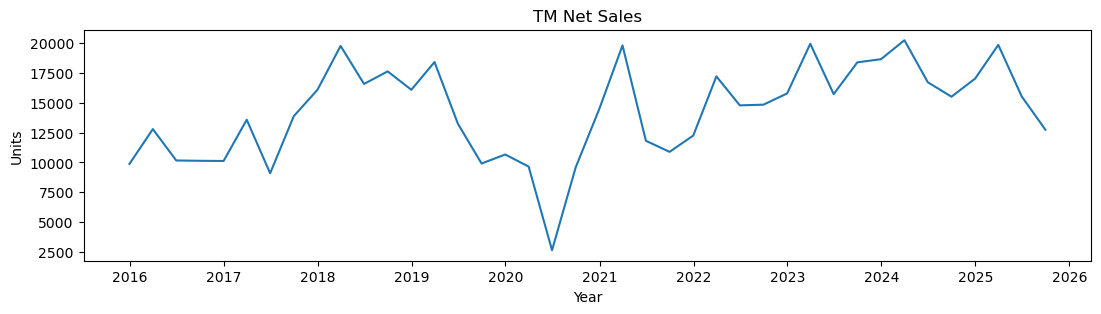

In [11]:
# Plotting the TS
plt.figure(figsize =(13,3))
plt.title("TM Net Sales")
plt.xlabel('Year')
plt.ylabel('Units')
plt.plot(df['Net Sales'])
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df['Net Sales'])
print(f"ADF Statistic: {adf_result[0]:.2f}")
print(f"p-value: {adf_result[1]:.2f}")

ADF Statistic: -2.52
p-value: 0.11


<Axes: xlabel='Date'>

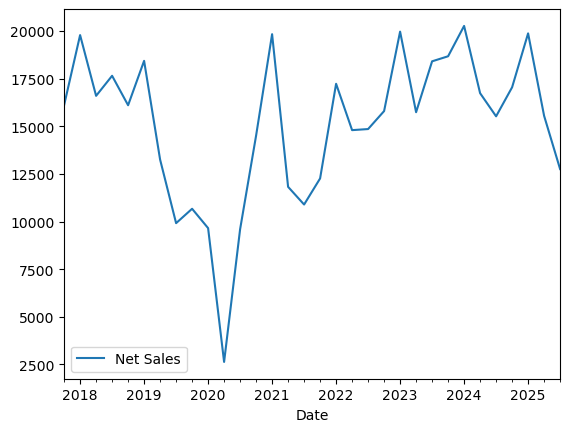

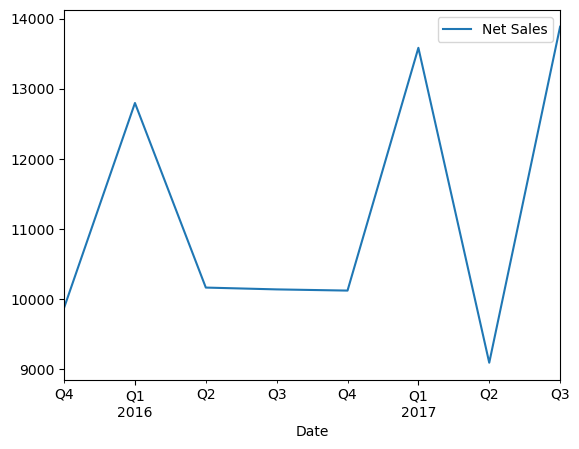

In [13]:
# Splitting the dataset into training and testing datasets 90% training and 10% testing data
import numpy as np
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, train_size=0.80, shuffle = False)
df_train.plot()
df_test.plot()

In [14]:
!pip install pmdarima

In [15]:
# Model development using df_train dataset
from pmdarima.arima import auto_arima
auto_arima_model = auto_arima(df_train,start_p=0, d=1, start_q=0, max_p=5,max_d=5,max_q=5,start_P=0,D=1,start_Q=0,test='adf',
max_P=5,max_D=5,Max_Q=5, m=12, seasonal = True, trace=True, error_action='warn', suppress_warnings=True,stepwise=True,)
auto_arima_model_fit = auto_arima_model.fit(df_train)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=362.106, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=363.689, Time=0.10 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=363.856, Time=0.04 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=363.586, Time=0.05 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=363.429, Time=0.03 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=364.867, Time=0.06 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=361.694, Time=0.02 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=363.687, Time=0.03 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.17 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=363.472, Time=0.02 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=363.431, Time=0.05 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=361.857, Time=0.02 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=365.586, Time=0.03 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=363.633, Time=0.00 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]

In [16]:
# predicting test data set values 
n_periods = len(df_test)
test_predictions = pd.DataFrame(auto_arima_model_fit.predict(n_periods=n_periods))
test_predictions.columns=['testpredictions']

C:\Users\saiha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\saiha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [17]:
test_predictions

,testpredictions
32,11621.548394
33,4780.681545
34,11830.575963
35,12853.794677
36,12100.981067
37,15438.562703
38,20616.717433
39,18287.758596


In [18]:
# setting the index for the test predictions
test_predictions.index = df_test.index
test_predictions.index

DatetimeIndex(['2017-09-30', '2017-06-30', '2017-03-31', '2016-12-31',
               '2016-09-30', '2016-06-30', '2016-03-31', '2015-12-31'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [19]:
test_predictions['testpredictions'] = pd.DataFrame(test_predictions['testpredictions'], index=test_predictions.index)
test_predictions['testpredictions']

Date
2017-09-30    11621.548394
2017-06-30     4780.681545
2017-03-31    11830.575963
2016-12-31    12853.794677
2016-09-30    12100.981067
2016-06-30    15438.562703
2016-03-31    20616.717433
2015-12-31    18287.758596
Name: testpredictions, dtype: float64

In [22]:
df_test['testpredictions'] = test_predictions.round(2)
df_test.head()

,Net Sales,testpredictions
Date,,
2017-09-30,13887,11621.55
2017-06-30,9094,4780.68
2017-03-31,13586,11830.58
2016-12-31,10123,12853.79
2016-09-30,10140,12100.98


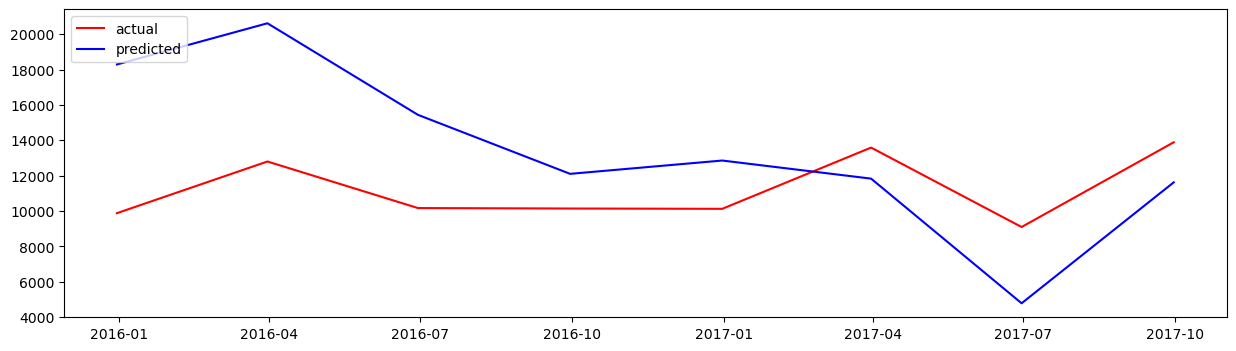

In [24]:
# Plotting the test data actuals and predictions
plt.figure(figsize =(15,4))
plt.plot(df_test['Net Sales'], color='red', label='actual')
plt.plot(df_test['testpredictions'], color='blue', label='predicted')
plt.legend(loc="upper left")
plt.show()

In [25]:
df.tail()

,Net Sales
Date,
2016-12-31,10123
2016-09-30,10140
2016-06-30,10166
2016-03-31,12799
2015-12-31,9878


In [26]:
future_forecast = auto_arima_model.predict(n_periods=12)
future_forecast = pd.DataFrame(future_forecast, columns=['FuturePrediction'])
future_forecast.index = pd.date_range(start='2018-01-01',periods=12,freq='MS')

C:\Users\saiha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\saiha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [27]:
# Predicting 12 months future values, creating the index
future_forecast.index = pd.date_range(start='2025-09-01', periods= 12, freq='MS')

In [28]:
future_forecast.index

DatetimeIndex(['2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
               '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01'],
              dtype='datetime64[ns]', freq='MS')

In [30]:
# Predicting next 12 months and storing them in a dataframe, naming the column of the dataframe 
Futurepredicted_values = pd.DataFrame(auto_arima_model_fit.predict(12))
Futurepredicted_values.columns = ['FuturePredictions']
Futurepredicted_values

C:\Users\saiha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\saiha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,FuturePredictions
32,11621.548394
33,4780.681545
34,11830.575963
35,12853.794677
36,12100.981067
37,15438.562703
38,20616.717433
39,18287.758596
40,19832.769546
41,18780.772459


In [31]:
# Creating indices with future dates for the future predicted values
Futurepredicted_values.index = pd.date_range(start='2025-09-01', periods= 12, freq='MS')
Futurepredicted_values

,FuturePredictions
2025-09-01,11621.548394
2025-10-01,4780.681545
2025-11-01,11830.575963
2025-12-01,12853.794677
2026-01-01,12100.981067
2026-02-01,15438.562703
2026-03-01,20616.717433
2026-04-01,18287.758596
2026-05-01,19832.769546
2026-06-01,18780.772459


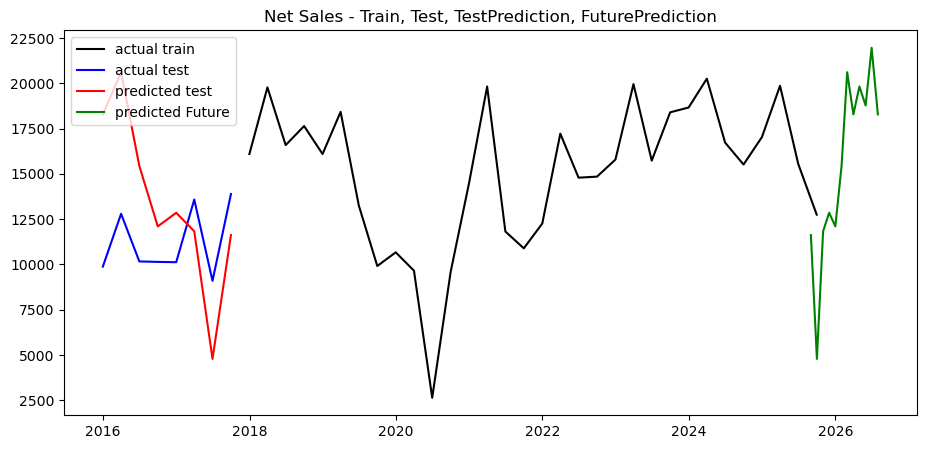

In [34]:
plt.figure(figsize =(11,5))
plt.plot(df_train['Net Sales'], color='black', label='actual train')
plt.plot(df_test['Net Sales'], color='blue', label='actual test')
plt.plot(df_test['testpredictions'], color='red', label='predicted test')
plt.plot(Futurepredicted_values['FuturePredictions'], color='green', label='predicted Future')
plt.title("Net Sales - Train, Test, TestPrediction, FuturePrediction")
plt.legend(loc="upper left")
plt.show()

In [35]:
# evaluate the model - df_test['production'], df_test['testpredictions']
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

mae = mean_absolute_error(df_test['Net Sales'], df_test['testpredictions'])
mse = mean_squared_error(df_test['Net Sales'], df_test['testpredictions'])
rmse = root_mean_squared_error(df_test['Net Sales'], df_test['testpredictions'])
r_squared = r2_score(df_test['Net Sales'], df_test['testpredictions'])

print('R-squared value:%.3f' %r_squared) # r-squared will be negative when the model is good and need to recheck the parameters or try another model
print('root_mean_squared_error:%.3f' %rmse)
print('mean_absolute_error: %.3f' % mae)
print('mean_squared_error: %.3f' % mse)

R-squared value:-6.909
root_mean_squared_error:4971.944
mean_absolute_error: 4315.750
mean_squared_error: 24720230.912
